# CellChatPy analysis of spatial multiomics data

This tutorial demonstrates CellChatPy inference and visualization for spatial multi-modal cell-cell communication using a SPOTS mouse spleen dataset. The input contains matched RNA expression, ADT protein abundance, cell labels, and 10X Visium spatial coordinates.

The workflow preprocesses RNA and ADT together, creates a spatial CellChat object, infers ligand-receptor and pathway communication probabilities, and visualizes the IL16 pathway on both the inferred network and tissue coordinates.

## Setup and imports

The setup cell locates the repository from either the project root or `tutorial/`, imports the local `CellChatPy` package, and defines one helper that saves, displays, and closes each Matplotlib figure exactly once.

In [1]:
from pathlib import Path
import pickle
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", message="divide by zero encountered in log")

project_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "CellChatPy").is_dir() and (path / "data").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Cannot locate a repository containing CellChatPy/ and data/.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc

%matplotlib inline

data_path = project_root / "data" / "mouse_spleen_spatial_multiomics.h5"
figure_dir = (project_root / "tutorial" / "figures_spatial_multiomics").resolve()
result_dir = (project_root / "results_spots_mouse_spleen").resolve()
figure_dir.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None

    path = figure_dir / name
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: {type(exc).__name__}: {exc}"
        ) from exc

    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)
    return None

print("CellChatPy:", cc.__version__)
print("Repository:", project_root)
print("Input:", data_path)

c:\anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CellChatPy: 1.1.0
Repository: E:\Jin\cellchat.python_new
Input: E:\Jin\cellchat.python_new\data\mouse_spleen_spatial_multiomics.h5


---

## Part I: Load and validate spatial multiomics inputs

CellChatPy requires matched RNA, ADT, metadata, and full-resolution spatial coordinates. RNA and ADT must both use spots as rows, retain their feature names, and have identical spot identifiers in the same order.

For 10X Visium, `ratio` converts full-resolution pixels to micrometers and `tol` is usually half the theoretical spot diameter. The validation below makes these contracts explicit before multiomics preprocessing begins.

### Load the canonical spatial H5 file

In [2]:
ptm = time.time()

inputs = cc.read_spatial_h5(data_path)

rna_values = inputs["expression"]
adt = inputs["modalities"]["adt"].copy()
metadata = inputs["metadata"].copy()
coordinates = inputs["coordinates"].copy()
spatial_factors = inputs["spatial_factors"]
genes = [str(gene) for gene in inputs["genes"]]
spots = [str(spot) for spot in inputs["cells"]]

if rna_values.shape != (len(spots), len(genes)):
    raise ValueError("RNA must have shape (number of spots, number of genes).")
if len(set(spots)) != len(spots) or len(set(genes)) != len(genes):
    raise ValueError("Spot names and RNA gene names must each be unique.")
rna_numeric_values = rna_values.data if hasattr(rna_values, "data") else np.asarray(rna_values)
if not np.isfinite(rna_numeric_values).all():
    raise ValueError("RNA expression must contain only finite values.")
if metadata.index.astype(str).tolist() != spots:
    raise ValueError("metadata must be indexed in the same order as RNA.")
if coordinates.index.astype(str).tolist() != spots:
    raise ValueError("coordinates must be indexed in the same order as RNA.")
if adt.index.astype(str).tolist() != spots:
    raise ValueError("ADT must be indexed in the same order as RNA.")
if not adt.columns.is_unique or not np.isfinite(adt.to_numpy(dtype=float)).all():
    raise ValueError("ADT feature names must be unique and values must be finite.")
required_columns = {"cellchat_group", "cellchat_dataset"}
missing_columns = required_columns.difference(metadata.columns)
if missing_columns:
    raise ValueError(f"metadata is missing required columns: {sorted(missing_columns)}")
if metadata[list(required_columns)].isna().any().any():
    raise ValueError("CellChat grouping and dataset labels cannot contain missing values.")
if not np.isfinite(coordinates.to_numpy(dtype=float)).all():
    raise ValueError("Spatial coordinates must contain only finite numeric values.")
dataset_count = metadata["cellchat_dataset"].nunique()
for factor_name in ("ratio", "tol"):
    factor = np.asarray(spatial_factors[factor_name], dtype=float).reshape(-1)
    if factor.size != dataset_count or not np.isfinite(factor).all() or np.any(factor <= 0):
        raise ValueError(
            f"spatial_factors[{factor_name!r}] must contain one finite positive value per dataset."
        )

# The H5 RNA matrix is sparse and unlabeled; restore its canonical labels.
rna = pd.DataFrame.sparse.from_spmatrix(rna_values, index=spots, columns=genes)

print(f"RNA: {rna.shape[0]:,} spots x {rna.shape[1]:,} genes")
print(f"ADT: {adt.shape[0]:,} spots x {adt.shape[1]:,} proteins")
print(f"1 pixel = {spatial_factors['ratio'][0]:.4f} um")

display(metadata["cellchat_group"].value_counts(sort=False).to_frame("spots"))

RNA: 2,568 spots x 3,023 genes
ADT: 2,568 spots x 21 proteins
1 pixel = 2.9967 um


,spots
cellchat_group,
B-cells,897
Mac-1,866
Mac-2,467
T-cells,338


### Integrate RNA and ADT features

`preprocess_multiomics` rescales both modalities, thresholds the ADT data, maps antibody names to mouse CellChatDB gene symbols, and keeps ligand-receptor pairs supported by the measured RNA and ADT features. Supplying labeled DataFrames is essential: it preserves real spot and feature names instead of generating placeholder labels.

In [3]:
db_mouse = cc.load_database("mouse")
multiomics = cc.preprocess_multiomics([rna, adt], database=db_mouse)
data_input = multiomics["expression"]
db_use = multiomics["database"]

if data_input.index.astype(str).tolist() != spots:
    raise AssertionError("Spot names changed during multiomics preprocessing.")
required_features = ["Il16", "CD4"]
missing_features = [feature for feature in required_features if feature not in data_input.columns]
if missing_features:
    raise ValueError(f"Required IL16 features are missing after preprocessing: {missing_features}")

print(f"Combined input: {data_input.shape[0]:,} spots x {data_input.shape[1]:,} features")
print(f"Multiomics database: {len(db_use['interaction']):,} interactions")
il16_database = db_use["interaction"].loc[
    db_use["interaction"]["pathway_name"].astype(str).eq("IL16"),
    ["interaction_name", "pathway_name", "ligand", "receptor", "annotation"],
]
if il16_database.empty:
    raise ValueError("The preprocessed multiomics database contains no IL16 interaction.")
display(il16_database)

Combined input: 2,568 spots x 3,044 features
Multiomics database: 29 interactions


,interaction_name,pathway_name,ligand,receptor,annotation
IL16_CD4,IL16_CD4,IL16,Il16,CD4,Secreted Signaling


### Create the spatial CellChat object

Create a CellChat object from a data matrix


c:\anaconda\envs\pytorch\Lib\site-packages\anndata\_core\anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Cell groups used for CellChat analysis: ['B-cells', 'Mac-1', 'Mac-2', 'T-cells']
Create a CellChat object from spatial transcriptomics data...
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\00_spatial_annotations.png


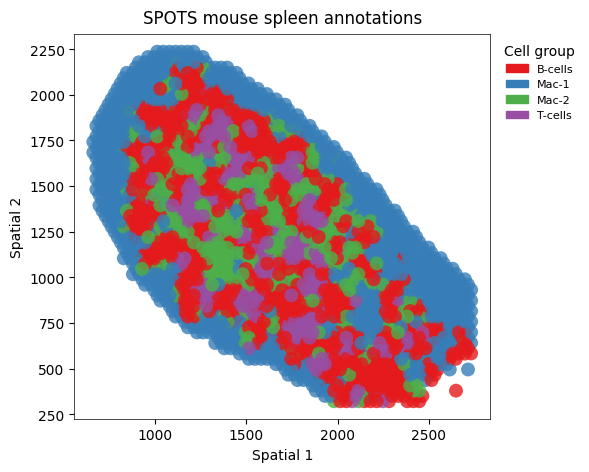

An object of class CellChat created from a single dataset
3044 genes, 2568 cells
CellChat analysis of SPATIAL data!
The input spatial locations are:
                         0       1
AAACACCAATAACTGC-1   928.0  2033.0
AAACAGAGCGACTCCT-1  2180.0   727.0
AAACAGCTTTCAGAAG-1   761.0  1568.0
AAACAGGGTCTATATT-1   828.0  1684.0
AAACCGGGTAGGTACC-1  1078.0  1539.0
Groups: ['B-cells', 'Mac-1', 'Mac-2', 'T-cells']


In [4]:
cellchat = cc.create_cellchat(
    object=data_input,
    metadata=metadata,
    group_by="cellchat_group",
    datatype="spatial",
    coordinates=coordinates,
    spatial_factors=spatial_factors,
)
if cellchat.obs_names.astype(str).tolist() != spots:
    raise AssertionError("CellChat spot names changed during object creation.")
if cellchat.var_names.astype(str).tolist() != data_input.columns.astype(str).tolist():
    raise AssertionError("CellChat feature names changed during object creation.")

cellchat = cc.set_database(cellchat, database=db_use)

color_use = cc.sc_palette(len(cellchat.groups.categories))
fig = cc.plot_spatial_dim(
    cellchat,
    color_use=color_use,
    title_name="SPOTS mouse spleen annotations",
    pt_size=10,
    fig_size=(6, 6),
    return_fig=True,
)
save_fig(fig, "00_spatial_annotations.png")

print(cellchat)
print("Groups:", list(cellchat.groups.categories))

### Identify candidate signaling interactions

CellChat subsets the signaling features and then identifies over-expressed
ligands, receptors, and ligand-receptor pairs. With `variable_both=False`,
either member of a ligand-receptor pair can drive the pair
into the candidate set.

In [5]:
cellchat = cc.subset_signaling_data(cellchat)
cellchat = cc.identify_overexpressed_genes(cellchat)
cellchat = cc.identify_overexpressed_interactions(cellchat, variable_both=False)

lr_sig = cellchat.lr_pairs["significant"]
print(f"Candidate over-expressed L-R pairs: {len(lr_sig):,}")
display(lr_sig[["interaction_name", "pathway_name", "ligand", "receptor"]].head(10))

The number of highly variable ligand-receptor pairs used for signaling inference is 29
Candidate over-expressed L-R pairs: 29


,interaction_name,pathway_name,ligand,receptor
IL16_CD4,IL16_CD4,IL16,Il16,CD4
LGALS9_CD45,LGALS9_B220-CD45R,GALECTIN,Lgals9,B220-CD45R
LGALS9_IGHM,LGALS9_IGM,GALECTIN,Lgals9,IgM
SELL_MADCAM1,SELL_MADCAM1,SELL,Sell,MadCAM1
PECAM1_PECAM1,CD31_CD31,PECAM1,CD31,CD31
H2-OB_CD4,H2-OB_CD4,MHC-II,H2-Ob,CD4
H2-OA_CD4,H2-OA_CD4,MHC-II,H2-Oa,CD4
H2-DMB2_CD4,H2-DMB2_CD4,MHC-II,H2-DMb2,CD4
H2-DMB1_CD4,H2-DMB1_CD4,MHC-II,H2-DMb1,CD4
H2-DMA_CD4,H2-DMA_CD4,MHC-II,H2-DMa,CD4


---

## Part II: Infer spatial communication

This example follows the R spatial multiomics vignette with a 10% truncated mean for group-level expression, spatial distance weighting, a 250 micrometer diffusion range, and a 100 micrometer contact range for low-resolution Visium data.

The tutorial uses `n_boot=20` for a reasonably quick demonstration. Increase the number of permutations for a final biological analysis when runtime permits.

### Compute communication probabilities

In [6]:
n_boot = 20
inference_started = time.time()

cellchat = cc.compute_communication_probability(
    cellchat,
    type_method="truncatedMean",
    trim=0.1,
    distance_use=True,
    interaction_range=250,
    scale_distance=0.01,
    contact_dependent=True,
    contact_range=100,
    n_boot=n_boot,
    seed_use=1,
)

cellchat = cc.filter_communication(cellchat, min_cells=10)

df_net = cc.subset_communication(cellchat, slot_name="network", thresh_pval=0.05)

print(f"Significant cell-group/L-R communications: {len(df_net):,}")
display(df_net.head(10))

truncatedMean is used for calculating the average gene expression per cell group.
Pre-computing 20 bootstrap averaged expressions...
Computing communication probabilities for 29 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Significant cell-group/L-R communications: 121


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,B-cells,T-cells,Il16,CD4,0.033580,0.0,IL16_CD4,Il16 - CD4,IL16,Secreted Signaling,KEGG: mmu04060
1,Mac-1,T-cells,Il16,CD4,0.011360,0.0,IL16_CD4,Il16 - CD4,IL16,Secreted Signaling,KEGG: mmu04060
2,Mac-2,T-cells,Il16,CD4,0.024818,0.0,IL16_CD4,Il16 - CD4,IL16,Secreted Signaling,KEGG: mmu04060
3,T-cells,T-cells,Il16,CD4,0.039740,0.0,IL16_CD4,Il16 - CD4,IL16,Secreted Signaling,KEGG: mmu04060
4,B-cells,B-cells,Lgals9,B220-CD45R,0.015953,0.0,LGALS9_B220-CD45R,Lgals9 - B220-CD45R,GALECTIN,Secreted Signaling,PMID: 30120235
5,Mac-1,B-cells,Lgals9,B220-CD45R,0.009067,0.0,LGALS9_B220-CD45R,Lgals9 - B220-CD45R,GALECTIN,Secreted Signaling,PMID: 30120235
6,Mac-2,B-cells,Lgals9,B220-CD45R,0.015540,0.0,LGALS9_B220-CD45R,Lgals9 - B220-CD45R,GALECTIN,Secreted Signaling,PMID: 30120235
7,T-cells,B-cells,Lgals9,B220-CD45R,0.014563,0.0,LGALS9_B220-CD45R,Lgals9 - B220-CD45R,GALECTIN,Secreted Signaling,PMID: 30120235
8,B-cells,B-cells,Lgals9,IgM,0.000477,0.0,LGALS9_IGM,Lgals9 - IgM,GALECTIN,Secreted Signaling,PMID: 30120235
9,B-cells,Mac-2,Lgals9,IgM,0.002141,0.0,LGALS9_IGM,Lgals9 - IgM,GALECTIN,Secreted Signaling,PMID: 30120235


### Infer pathway-level communication

In [7]:
cellchat = cc.compute_pathway_probability(cellchat, thresh=0.05)
cellchat = cc.aggregate_network(cellchat, thresh=0.05)

pathways = list(cellchat.pathway_network.get("prob", {}))
print(f"Significant pathways ({len(pathways)}):")
print(", ".join(pathways))

df_pathway = cc.subset_communication(
    cellchat, slot_name="pathway_network", thresh_pval=0.05
)
df_il16 = df_pathway.loc[df_pathway["pathway_name"].astype(str).eq("IL16")].copy()
if df_il16.empty:
    raise ValueError("IL16 was not significant at the pathway level.")

print(f"Inference elapsed: {time.time() - inference_started:.1f} seconds")
display(df_il16)

Pathway-level results stored in .pathway_network.
Significant pathways (9):
MHC-II, MHC-I, PECAM2, PECAM1, CD45, IL16, GALECTIN, SN, SELL
Inference elapsed: 1.7 seconds


,source,target,pathway_name,prob,pval
21,B-cells,T-cells,IL16,0.033580,0.0
22,Mac-1,T-cells,IL16,0.011360,0.0
23,Mac-2,T-cells,IL16,0.024818,0.0
24,T-cells,T-cells,IL16,0.039740,0.0


---

## Part III: Visualize the communication network

The R spatial multiomics vignette highlights IL16 signaling. The chord plot summarizes the inferred pathway-level network, while the spatial plot places the same signaling pathway back on the tissue coordinates.

### Visualize IL16 communication

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\01_IL16_chord.png


c:\anaconda\envs\pytorch\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning: invalid value encountered in divide
  return (mat[i, :] / x[i]) * (end - start)


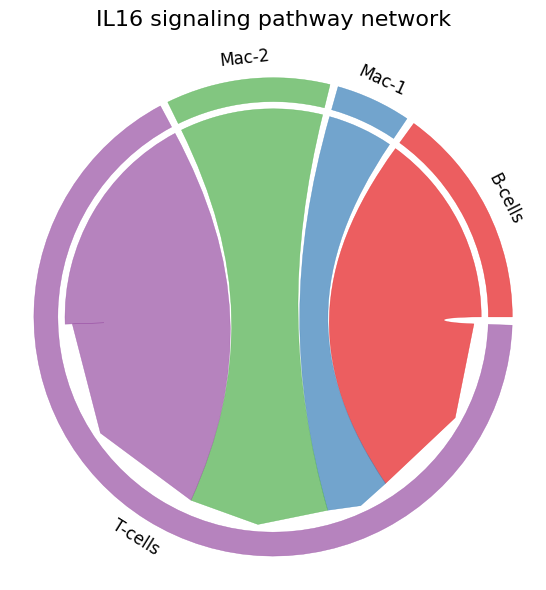

In [8]:
pathway_show = "IL16"
if pathway_show not in pathways:
    raise ValueError(
        f"{pathway_show!r} was not inferred. Available pathways: {pathways}"
    )

fig = cc.plot_network_aggregate(
    cellchat,
    signaling=pathway_show,
    layout="chord",
    title_name="IL16 signaling pathway network",
    fig_size=(7, 6),
    return_fig=True,
)
save_fig(fig, "01_IL16_chord.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\02_IL16_spatial_network.png


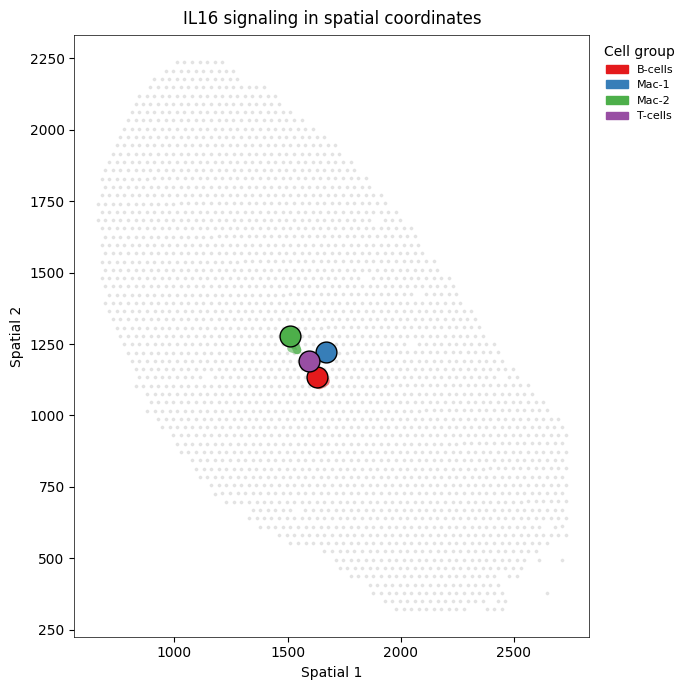

In [9]:
fig = cc.plot_network_spatial(
    cellchat,
    signaling=pathway_show,
    title_name="IL16 signaling in spatial coordinates",
    return_fig=True,
)
save_fig(fig, "02_IL16_spatial_network.png")

### Compute signaling-role centrality

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\03_IL16_signaling_roles.png


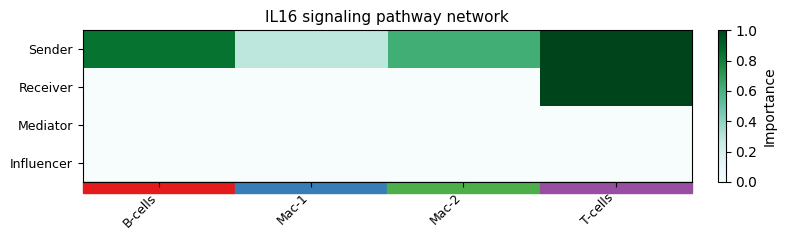

In [10]:
cellchat = cc.compute_network_centrality(cellchat, slot_name="pathway_network")

fig = cc.net_analysis_signaling_role_network(
    cellchat,
    signaling=pathway_show,
    slot_name="pathway_network",
    font_size=9,
    fig_size=(8, 2.5),
    return_fig=True,
)
save_fig(fig, "03_IL16_signaling_roles.png")

### Plot RNA and ADT abundance on tissue

The combined CellChat matrix retains `Il16` as an RNA feature and `CD4` as the mapped ADT feature. Separate panels use independent color scales, matching the R vignette's distinction between ligand RNA expression and receptor protein abundance.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\04_spatial_RNA_Il16.png


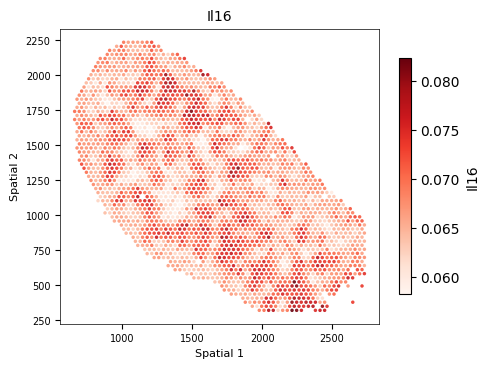

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\04_spatial_ADT_CD4.png


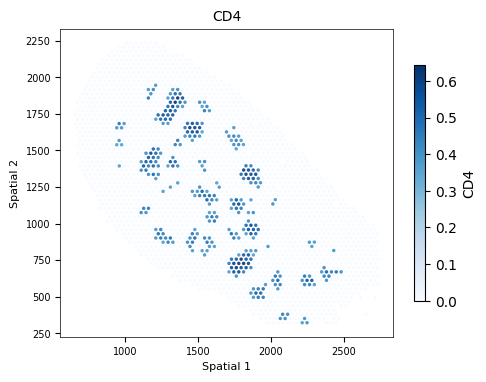

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_multiomics\05_spatial_IL16_features.png


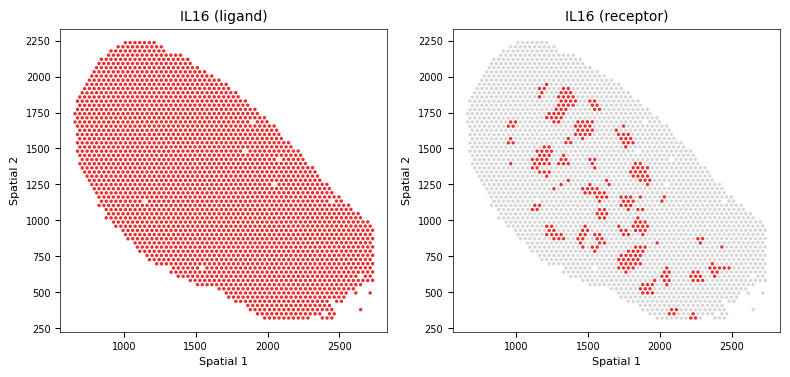

In [15]:
for feature, color_bar, filename in [
    ("Il16", "Reds", "04_spatial_RNA_Il16.png"),
    ("CD4", "Blues", "04_spatial_ADT_CD4.png"),
]:
    if feature not in cellchat.var_names:
        raise ValueError(f"Required spatial feature is missing: {feature}")
    fig = cc.plot_spatial_feature(
        cellchat,
        features=[feature],
        color_bar=color_bar,
        pt_size=2.5,
        ncol=1,
        fig_size=(5, 4),
        return_fig=True,
    )
    save_fig(fig, filename)

fig = cc.plot_spatial_feature(
    cellchat,
    signaling=pathway_show,
    color_bar="Reds",
    pt_size=2.5,
    ncol=2,
    fig_size=(8, 4),
    return_fig=True,
)
save_fig(fig, "05_spatial_IL16_features.png")

---

## Part IV: Save results

Communication tables are convenient for downstream analysis, while pickle preserves the full Python `CellChat` object. Export is opt-in so running the tutorial does not unexpectedly overwrite result files; set `export_results = True` when these artifacts are needed.

In [12]:
export_results = False

summary = pd.Series(
    {
        "spots": len(metadata),
        "cell_groups": metadata["cellchat_group"].nunique(),
        "database_interactions": len(db_use["interaction"]),
        "candidate_lr_pairs": len(lr_sig),
        "significant_lr_communications": len(df_net),
        "significant_pathways": len(pathways),
        "pixel_to_um": float(spatial_factors["ratio"][0]),
        "analysis_seconds": time.time() - ptm,
    },
    name="value",
)
display(summary.to_frame())

if export_results:
    result_dir.mkdir(parents=True, exist_ok=True)
    lr_path = result_dir / "inferred_ligand_receptor_communications.csv"
    pathway_path = result_dir / "inferred_pathway_communications.csv"
    summary_path = result_dir / "analysis_summary.csv"
    object_path = result_dir / "cellchat_SPOTS_mouse_spleen.pkl"

    df_net.to_csv(lr_path, index=False)
    df_pathway.to_csv(pathway_path, index=False)
    summary.to_csv(summary_path, header=True)
    with object_path.open("wb") as handle:
        pickle.dump(cellchat, handle, protocol=pickle.HIGHEST_PROTOCOL)

    print("L-R table:", lr_path)
    print("Pathway table:", pathway_path)
    print("Summary:", summary_path)
    print("CellChat object:", object_path)
else:
    print("Set export_results=True to write communication tables and the CellChat object.")

,value
spots,2568.000000
cell_groups,4.000000
database_interactions,29.000000
candidate_lr_pairs,29.000000
significant_lr_communications,121.000000
significant_pathways,9.000000
pixel_to_um,2.996668
analysis_seconds,6.067772


Set export_results=True to write communication tables and the CellChat object.


## Workflow summary

The complete CellChatPy workflow used in this notebook is:

1. Load matched RNA, ADT, metadata, coordinates, and spatial factors with `read_spatial_h5`.
2. Restore labels on the sparse RNA matrix and integrate RNA with ADT using `preprocess_multiomics`.
3. Create a spatial `CellChat` object and identify candidate signaling interactions.
4. Infer spatially constrained ligand-receptor and pathway communication.
5. Analyze IL16 signaling and distinguish RNA expression from ADT protein abundance in tissue plots.

For another spatial multiomics platform, preserve modality labels and spot alignment, then derive `ratio`, `tol`, interaction range, and contact range from that platform's physical geometry.

### Session information

In [13]:
print(f"Python: {platform.python_version()}")
print(f"CellChatPy: {cc.__version__}")
print(f"pandas: {pd.__version__}")

Python: 3.11.13
CellChatPy: 1.1.0
pandas: 3.0.3
